In [2]:
# core point : 반지름안에 있는 점들을 찾는 문제
# core point >= min_samples(최소기준)
# core->core->core : 자연스럽게 군집을 형성
# 밀도가 높은 곳은 계속 연결되어 있다->하나의 큰 덩어리인 클러스터
# 반지름안에 있는 점들을 찾는 문제는 주어진 중심점과 반지름을 기준으로, 
# 해당 반지름 안에 위치한 점들을 찾는 문제입니다. 
# 이 문제는 주로 2차원 평면에서 다루어지며, 중심점과 반지름이 주어졌을 때, 
# 해당 반지름 안에 있는 점들의 좌표를 반환하는 방식으로 해결됩니다.
# - 이 문제를 해결하기 위해서는 다음과 같은 단계를 거칠 수 있습니다:  

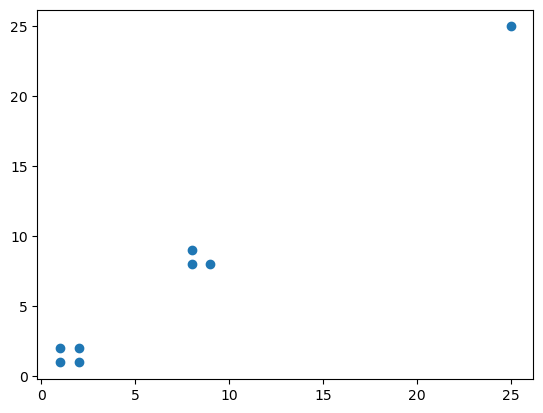

In [3]:
# 샘플데이터
import numpy as np
import matplotlib.pyplot as plt
X = np.array(
    [[1,1],[1,2],[2,1],[2,2],[8,8],[8,9],[9,8],[25,25]]
)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [4]:
import numpy as np
# 반지름 1.5안에 3개이상 있으면 core point
esp=1.5
min_samples=3
# 현재점 p0(1,1)
round(np.sqrt((2-1)**2 + (2-1)**2),1)
# 이웃 4
# p0(1,1) p1(1,2) p2(2,1) p3(2,2)
# 주변찾기 p1->p2->p3

np.float64(1.4)

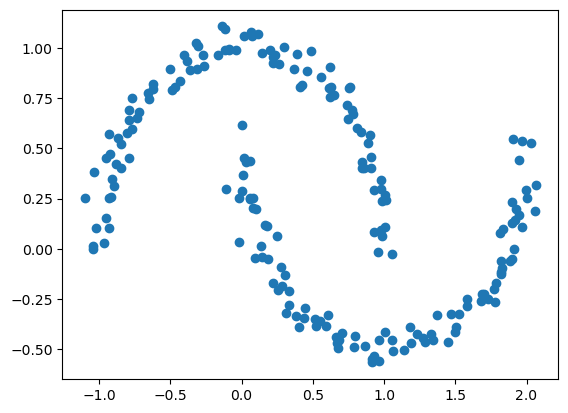

In [5]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import make_moons
np.random.seed(42)
X,y =  make_moons(
    n_samples=200,
    noise=0.05, random_state=42
)
plt.scatter(X[:,0], X[:,1])
plt.show()


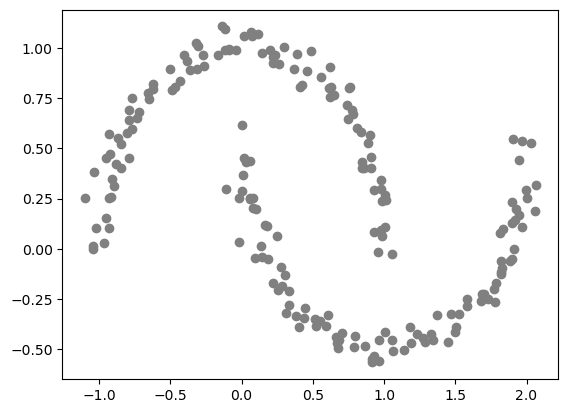

In [6]:
# step 1 초기화(모든점 미방문)
UNVISITED = -1
NOISE = -2
n = len(X)
labels = np.full(n, UNVISITED)

esp = 0.3
min_samples = 5
cluster_id = 0
plt.scatter(X[:,0], X[:,1],c='gray')
plt.show()

In [ ]:
# step 2 : 반경내 이웃찾기
def region_query(X, point_idx, esp):
    '''
    X : 전체데이터셋
    point_idx : 기준점 Core point후보 인덱스
    eps : 이웃으로인정하기위한 최대거리 즉 반경(Epsilon)
    '''
    distance = np.linalg.norm(    
        X - X[point_idx],
        axis=1  # 열단위로 연산
    )
    neighbors = np.where(distance <= esp)[0]    
    return neighbors

neighbors = [  0  23  57  59  61  68 132 148 152 171 186 197]
esp = 0.3
neighbors = [  0  23  57  59  61  68 132 148 152 171 186 197]
12
esp = 0.3
neighbors = [  0  23  26  49  57  59  61  68  85 128 132 148 149 152 171 186 188 197]
18
esp = 0.3
neighbors = [ 13  18  23  26  33  39  40  49  55  68  81  85 128 144 148 149 152 171
 188 189 194]
21
esp = 0.3
neighbors = [ 13  18  23  26  33  39  40  49  55  68  81  85 128 144 148 149 152 171
 188 189 194]
21
esp = 0.3
neighbors = [  6  13  18  26  33  39  40  49  55  81  85 114 128 144 149 159 188 189
 194]
19
esp = 0.3
neighbors = [  6  13  18  26  33  39  40  49  55  81  85 114 128 144 149 159 188 189
 194]
19
esp = 0.3
neighbors = [  6  13  18  26  33  39  40  49  55  68  81  85 114 128 144 149 159 188
 189 194]
20
esp = 0.3
neighbors = [ 13  18  23  26  33  39  40  49  68  81  85 128 132 144 148 149 152 171
 188 197]
20
esp = 0.3
neighbors = [  0  13  18  23  26  40  49  61  68  85 128 132 144 148 149 152 171 188
 197]
19
esp = 0.3
ne

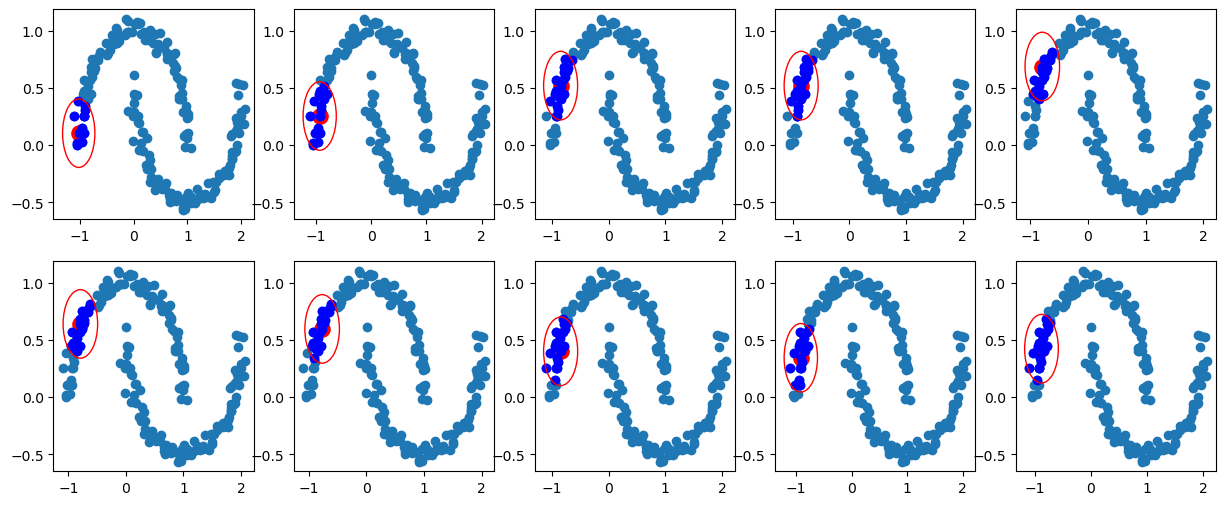

In [27]:
# step3 Core Pont 확인
neighbors = region_query(X, 0, esp)
esp = 0.3
fig, ax = plt.subplots(2,5,figsize=(15,6))
for i in range(10):
    point_index = neighbors[i]
    print(f'esp = {esp}')
    neighbors = region_query(X, point_index, esp)
    # 전체점
    ax[i//5, i%5].scatter(X[:,0], X[:,1])

    # 현재 점
    ax[i//5, i%5].scatter(
        X[point_index,0], X[point_index,1],
        c='red',s=120
    )
    # 이웃점
    ax[i//5, i%5].scatter(
        X[neighbors,0], X[neighbors,1],
        c='blue'
    )
    print(len(X[neighbors]))

    # esp 원
    circle = plt.Circle(
        X[point_index], esp, color='red',fill=False
    )
    ax[i//5, i%5].add_patch(circle)
plt.show()

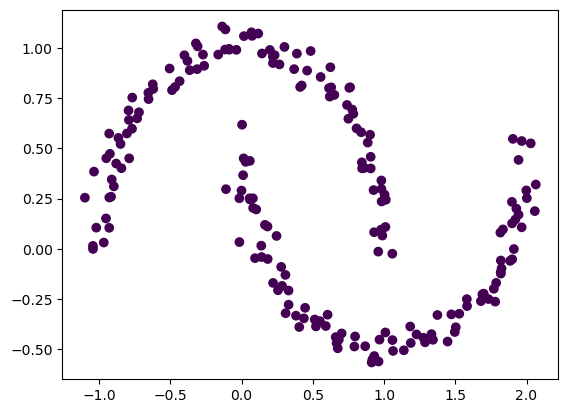

In [16]:
# 라이브러리 이용
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=0.5, min_samples=5)
sk_labels = model.fit_predict(X)
plt.scatter(
    X[:,0], X[:,1], c=sk_labels
)
plt.show()
